# Indian Literature BERT: Bias Direction vs Gender Affinity

Figure-7-style scatter using selective labeling and category colors.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

input_path = Path('outputs') / 'task4_phase4_word_bias.csv'
df = pd.read_csv(input_path)

df = df.rename(columns={
    'attribute_set': 'Category',
    'attribute_word': 'Attribute_Word',
    'mean_cosine_to_male': 'Male_Similarity',
    'mean_cosine_to_female': 'Female_Similarity',
    'bias_score': 'Bias_Score'
})

required = ['Category', 'Attribute_Word', 'Male_Similarity', 'Female_Similarity', 'Bias_Score']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df['Category'] = df['Category'].astype(str).str.replace('_', ' ').str.title()
df['Gender_Affinity'] = (df['Male_Similarity'] + df['Female_Similarity']) / 2.0

print(f'Loaded {len(df)} words from {input_path}')
df[['Category', 'Attribute_Word', 'Male_Similarity', 'Female_Similarity', 'Bias_Score', 'Gender_Affinity']].head()

Loaded 47 words from outputs\task4_phase4_word_bias.csv


,Category,Attribute_Word,Male_Similarity,Female_Similarity,Bias_Score,Gender_Affinity
0,Science,science,0.443738,0.412675,0.031063,0.428207
1,Science,mathematics,0.402017,0.383888,0.018129,0.392952
2,Science,math,0.376379,0.349489,0.026890,0.362934
3,Science,physics,0.385480,0.343390,0.042090,0.364435
4,Science,chemistry,0.317222,0.325695,-0.008473,0.321459


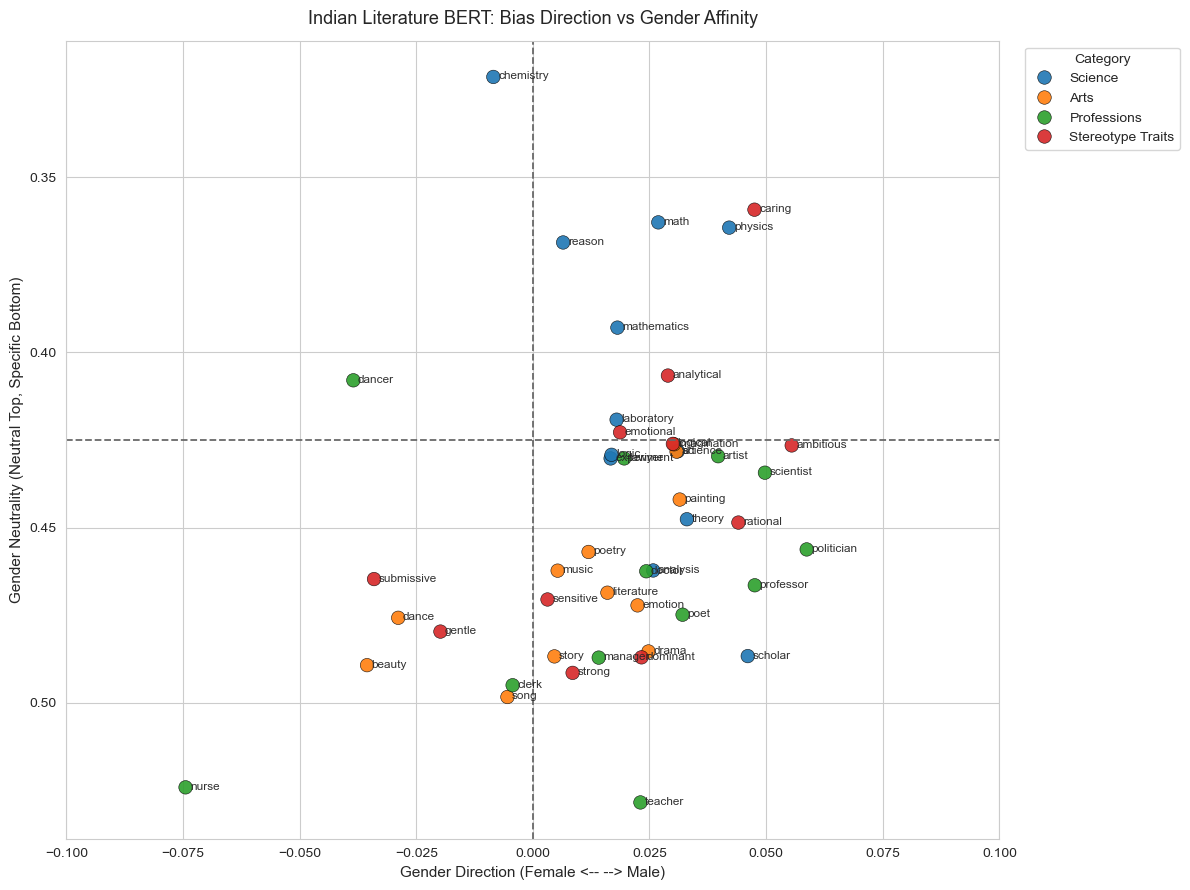

In [5]:
fig, ax = plt.subplots(figsize=(12, 9))

sns.scatterplot(
    data=df,
    x='Bias_Score',
    y='Gender_Affinity',
    hue='Category',
    palette='tab10',
    s=95,
    edgecolor='black',
    linewidth=0.4,
    alpha=0.9,
    ax=ax
)

x_lim = max(0.1, float(np.abs(df['Bias_Score']).max()) + 0.01)
ax.set_xlim(-x_lim, x_lim)

ax.axvline(0.0, linestyle='--', color='dimgray', linewidth=1.3)
y_mid = float((df['Gender_Affinity'].min() + df['Gender_Affinity'].max()) / 2.0)
ax.axhline(y_mid, linestyle='--', color='dimgray', linewidth=1.3)

# Selective labeling requested: label only strong male/female-similarity words.
for _, row in df.iterrows():
    male_score = row['Male_Similarity']
    female_score = row['Female_Similarity']
    if abs(male_score) > 0.02 or abs(female_score) > 0.02:
        ax.text(
            row['Bias_Score'] + 0.001,
            row['Gender_Affinity'] + 0.0007,
            row['Attribute_Word'],
            fontsize=8.5,
            alpha=0.95
        )

ax.invert_yaxis()
ax.set_xlabel('Gender Direction (Female <-- --> Male)', fontsize=11)
ax.set_ylabel('Gender Neutrality (Neutral Top, Specific Bottom)', fontsize=11)
ax.set_title('Indian Literature BERT: Bias Direction vs Gender Affinity', fontsize=13, pad=12)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
output_plot = Path('outputs') / 'indian_results_bias_affinity_scatter.png'
fig.savefig(output_plot, dpi=300, bbox_inches='tight')
print(f'Saved: {output_plot}')

Saved: outputs\indian_results_bias_affinity_scatter.png
